## First Question

In [1]:
import pandas as pd
import numpy as np

URL = "https://www.iposcoop.com/ipos-recently-filed/"

In [2]:
# ---------- 1. Load the table ----------
tables = pd.read_html(URL)
df = tables[0]

# Flatten multi-line column headers
df.columns = [' '.join(str(c).split()) for c in df.columns]
print("Columns:", df.columns.tolist())
print("Total rows:", len(df))

Columns: ['File Date', 'Company', 'Symbol', 'Managers', 'Shares (millions)', 'Price Low', 'Price High', 'Est $ Vol (millions)', 'Expected To Trade', 'SCOOP Rating']
Total rows: 500


In [3]:
# ---------- 2. Filter to Withdrawn ----------
w = df[df['Expected To Trade'].astype(str).str.strip().str.lower() == 'withdrawn'].copy()
print(f"\nWithdrawn entries: {len(w)}")

# (Optional) Restrict to file dates before 2026-09-11:
w['File Date'] = pd.to_datetime(w['File Date'])
w = w[w['File Date'] < pd.Timestamp('2026-09-11')]


Withdrawn entries: 35


In [4]:
# ---------- 3. Classify company type ----------
def classify(name: str) -> str:
    name = str(name)
    if 'Technologies' in name:
        return 'Technologies'
    if ('Acquisition Corp' in name) or ('Acquisition Corporation' in name) or ('Corp' in name):
        return 'Acquisition Corp'
    if ('Inc' in name) or ('Incorporated' in name):
        return 'Inc.'
    if 'Group' in name:
        return 'Group'
    if ('Ltd' in name) or ('Limited' in name):
        return 'Limited'
    if ('Holdings' in name) or ('Holding' in name):
        return 'Holdings'
    return 'Other'

w['Company Type'] = w['Company'].apply(classify)

In [5]:
# ---------- 4. Parse prices ----------
def parse_num(v):
    if pd.isna(v):
        return np.nan
    s = str(v).replace('$', '').replace(',', '').strip()
    if s in ('', '-', 'TBA', 'N/A', 'nan', 'None'):
        return np.nan
    try:
        return float(s)
    except ValueError:
        return np.nan

w['Price Low Num']  = w['Price Low'].apply(parse_num)
w['Price High Num'] = w['Price High'].apply(parse_num)

# Avg of low & high; if only one side is present, use that side
w['Avg_price'] = w[['Price Low Num', 'Price High Num']].mean(axis=1)

In [6]:
# ---------- 5. Numeric conversion for shares / volume ----------
w['Shares'] = w['Shares (millions)'].apply(parse_num)
w['EstVol'] = w['Est $ Vol (millions)'].apply(parse_num)

In [7]:
# ---------- 6. Shares_offered_value ----------
w['Shares_offered_value'] = w['Shares'] * w['Avg_price']
# If the product is null (either input missing), fall back to Est $ Vol
w['Shares_offered_value'] = w['Shares_offered_value'].fillna(w['EstVol'])

In [8]:
# ---------- 7. Aggregate by Company Type ----------
summary = (
    w.groupby('Company Type')['Shares_offered_value']
     .sum()
     .sort_values(ascending=False)
     .round(2)
)
print("\nTotal withdrawn IPO value by Company Type ($ millions):")
print(summary)

top_type  = summary.idxmax()
top_value = summary.max()
print(f"\nTop company type: {top_type}")
print(f"Total withdrawn IPO value: ${top_value:,.2f} million")


Total withdrawn IPO value by Company Type ($ millions):
Company Type
Acquisition Corp    499.98
Inc.                351.00
Holdings            311.66
Other               290.44
Limited             197.25
Technologies        184.90
Group                32.50
Name: Shares_offered_value, dtype: float64

Top company type: Acquisition Corp
Total withdrawn IPO value: $499.98 million


## Second Question

In [9]:
import yfinance as yf

# ============================================================
# 1. Load the 2025 IPO list
# ============================================================
URL = "https://www.iposcoop.com/2025-pricings/"
tables = pd.read_html(URL)
df = tables[0]
df.columns = [' '.join(str(c).split()) for c in df.columns]
print(f"Total 2025 IPOs loaded: {len(df)}")

Total 2025 IPOs loaded: 231


In [10]:
# ============================================================
# 2. Filter to Offer Date < 2025-09-01, then drop 0% returns
# ============================================================
df['Offer Date'] = pd.to_datetime(df['Offer Date'], format='%m/%d/%Y', errors='coerce')
df = df[df['Offer Date'] < pd.Timestamp('2025-09-01')].copy()
print(f"IPOs with Offer Date < 2025-09-01: {len(df)}")   # expect 148

# Exclude entries with 0% return
df['Return_num'] = (
    df['Return'].astype(str).str.replace('%', '', regex=False).astype(float)
)
df = df[df['Return_num'] != 0].copy()
print(f"After excluding 0% returns: {len(df)}")

tickers = df['Symbol'].dropna().astype(str).unique().tolist()
print(f"Unique tickers to download: {len(tickers)}")

IPOs with Offer Date < 2025-09-01: 163
After excluding 0% returns: 146
Unique tickers to download: 146


In [11]:
# ============================================================
# 3. Bulk download with yfinance (delisted tickers return empty)
# ============================================================
raw = yf.download(
    tickers,
    start='2025-01-01',
    end='2026-09-12',      # yfinance end is exclusive → includes 2026-09-11
    auto_adjust=False,
    progress=False,
    threads=True,
)

# Normalize to a wide 'Close' DataFrame (Date x Ticker)
if isinstance(raw.columns, pd.MultiIndex):
    close = raw['Close']
else:  # only one ticker succeeded
    close = raw[['Close']].rename(columns={'Close': tickers[0]})

# Drop tickers with no data at all (delisted / not on Yahoo)
close = close.dropna(axis=1, how='all')
print(f"Tickers with usable data: {close.shape[1]}")   # ~134

ERROR:yfinance:HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: EPWK"}}}
ERROR:yfinance:HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: CEPT"}}}
ERROR:yfinance:
14 Failed downloads:
ERROR:yfinance:['EPWK', 'CEPT', 'MJID', 'EMPG', 'SKBL', 'PTNM', 'SDM', 'CAEP', 'AGH', 'TBH', 'WGRX', 'MCTR', 'MTSR', 'AHL']: YFTzMissingError('possibly delisted; no timezone found')


Tickers with usable data: 132


In [12]:
# ============================================================
# 4. Reshape to long format and engineer features per ticker
# ============================================================
stocks_df = (
    close
    .stack()
    .rename_axis(['Date', 'Ticker'])
    .reset_index(name='Close')
)
stocks_df = stocks_df.sort_values(['Ticker', 'Date']).reset_index(drop=True)

# growth_252d = Close / Close.shift(252), applied per ticker
stocks_df['growth_252d'] = (
    stocks_df.groupby('Ticker')['Close']
             .transform(lambda s: s / s.shift(252))
)

# volatility = rolling(30).std() * sqrt(252), applied per ticker
stocks_df['volatility'] = (
    stocks_df.groupby('Ticker')['Close']
             .transform(lambda s: s.rolling(30).std() * np.sqrt(252))
)

# Sharpe with rf = 5%
stocks_df['Sharpe'] = (stocks_df['growth_252d'] - 0.05) / stocks_df['volatility']

In [13]:
# ============================================================
# 5. Snapshot for 2026-09-11
# ============================================================
snapshot = stocks_df[stocks_df['Date'] == pd.Timestamp('2026-09-11')].copy()

# Only stocks that have a valid 252d growth AND volatility
snapshot_valid = snapshot.dropna(subset=['growth_252d', 'volatility'])

print(f"\nStocks with full 252d history on 2026-09-11: {len(snapshot_valid)}")
print(f"Median Sharpe ratio: {snapshot_valid['Sharpe'].median():.4f}")
print(f"Mean   Sharpe ratio: {snapshot_valid['Sharpe'].mean():.4f}")

print("\nDescriptive statistics:")
print(
    snapshot_valid[['growth_252d', 'volatility', 'Sharpe']]
    .describe()
    .round(4)
)


Stocks with full 252d history on 2026-09-11: 130
Median Sharpe ratio: 0.0490
Mean   Sharpe ratio: inf

Descriptive statistics:
       growth_252d  volatility    Sharpe
count     130.0000    130.0000  130.0000
mean        1.0521     27.7841       inf
std         3.0492     67.0825       NaN
min         0.0010      0.0000   -0.0401
25%         0.1410      2.3259    0.0120
50%         0.5945      8.1223    0.0490
75%         1.0388     24.0199    0.1336
max        33.6383    627.6981       inf


In [14]:
# ============================================================
# 6. Extra diagnostics requested
# ============================================================
print("\n--- Growth vs. Sharpe ---")
print(f"Median growth_252d: {snapshot_valid['growth_252d'].median():.4f}")
print(f"Mean   growth_252d: {snapshot_valid['growth_252d'].mean():.4f}")

print("\nTop 10 by Sharpe (risk-adjusted winners):")
cols = ['Ticker', 'growth_252d', 'volatility', 'Sharpe']
print(
    snapshot_valid.sort_values('Sharpe', ascending=False)
                  .head(10)[cols]
                  .round(4)
                  .to_string(index=False)
)

print("\nTop 10 by growth_252d (pure growth):")
print(
    snapshot_valid.sort_values('growth_252d', ascending=False)
                  .head(10)[cols]
                  .round(4)
                  .to_string(index=False)
)


--- Growth vs. Sharpe ---
Median growth_252d: 0.5945
Mean   growth_252d: 1.0521

Top 10 by Sharpe (risk-adjusted winners):
Ticker  growth_252d  volatility  Sharpe
  MAGH       5.4516      0.0000     inf
  EFTY       2.1066      0.0000     inf
  MAMK       6.5327      0.0000     inf
 HCMAU       1.0346      0.1828  5.3853
  CEPF       1.0242      0.3516  2.7710
  TMDE       0.7762      0.4147  1.7512
  TLIH       0.9897      0.6485  1.4489
  CEPO       1.0312      0.7953  1.2338
  HXHX       0.4096      0.4774  0.7532
  FBGL       0.5769      0.8380  0.6288

Top 10 by growth_252d (pure growth):
Ticker  growth_252d  volatility  Sharpe
  MGRT      33.6383    131.1160  0.2562
  MAMK       6.5327      0.0000     inf
  BUUU       5.9309     69.7924  0.0843
  MAGH       5.4516      0.0000     inf
   ALM       3.4809     36.3990  0.0943
  XHLD       2.4497     52.9911  0.0453
  RYOJ       2.2683      7.1972  0.3082
  EFTY       2.1066      0.0000     inf
  SLDE       1.8468     24.0713  0.074

## Third Question

In [15]:
# ============================================================
# 0. (Rebuild stocks_df if not already in memory)
# ============================================================
URL = "https://www.iposcoop.com/2025-pricings/"
df = pd.read_html(URL)[0]
df.columns = [' '.join(str(c).split()) for c in df.columns]
df['Offer Date'] = pd.to_datetime(df['Offer Date'], format='%m/%d/%Y', errors='coerce')
df = df[df['Offer Date'] < pd.Timestamp('2025-09-01')].copy()
df['Return_num'] = df['Return'].astype(str).str.replace('%', '', regex=False).astype(float)
df = df[df['Return_num'] != 0].copy()

tickers = df['Symbol'].dropna().astype(str).unique().tolist()

raw = yf.download(
    tickers,
    start='2025-01-01',
    end='2026-09-12',
    auto_adjust=False,
    progress=False,
    threads=True,
)
close = raw['Close'] if isinstance(raw.columns, pd.MultiIndex) else raw[['Close']]
close = close.dropna(axis=1, how='all')

stocks_df = (
    close.stack()
         .rename_axis(['Date', 'Ticker'])
         .reset_index(name='Close')
         .sort_values(['Ticker', 'Date'])
         .reset_index(drop=True)
)

ERROR:yfinance:
14 Failed downloads:
ERROR:yfinance:['EPWK', 'CEPT', 'MJID', 'EMPG', 'SKBL', 'PTNM', 'SDM', 'CAEP', 'AGH', 'TBH', 'WGRX', 'MCTR', 'MTSR', 'AHL']: YFTzMissingError('possibly delisted; no timezone found')


In [16]:
# ============================================================
# 1. Build the 12 forward-growth columns per ticker
#    (1 month = 21 trading days, up to 12 months = 252 days)
# ============================================================
HORIZONS = {f'future_growth_{m}_m': 21 * m for m in range(1, 13)}

def add_forward_growth(g):
    """For each ticker's sorted series, compute Close[t+h]/Close[t] for each horizon."""
    g = g.sort_values('Date').reset_index(drop=True)
    c = g['Close']
    for col, h in HORIZONS.items():
        g[col] = c.shift(-h) / c
    return g

stocks_df = (
    stocks_df
    .groupby('Ticker', group_keys=False)
    .apply(add_forward_growth)
    .reset_index(drop=True)
)

/tmp/ipykernel_1668/1471339404.py:18: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(add_forward_growth)


In [17]:
# ============================================================
# 2. Identify the first available trading day per ticker (IPO entry)
# ============================================================
entry = (
    stocks_df
    .sort_values(['Ticker', 'Date'])
    .groupby('Ticker', as_index=False)
    .first()[['Ticker', 'Date', 'Close']]
    .rename(columns={'Date': 'IPO_Date', 'Close': 'IPO_Close'})
)
print(f"Tickers with an IPO entry row: {len(entry)}")

Tickers with an IPO entry row: 132


In [18]:
# ============================================================
# 3. Inner-join entry rows with the full growth table
#    so we keep only the growth numbers measured FROM the IPO date
# ============================================================
ipo_growth = entry.merge(
    stocks_df[['Ticker', 'Date'] + list(HORIZONS.keys())],
    left_on=['Ticker', 'IPO_Date'],
    right_on=['Ticker', 'Date'],
    how='inner'
).drop(columns=['Date'])

print(f"IPO-aligned rows: {len(ipo_growth)}")

IPO-aligned rows: 132


In [19]:
# ============================================================
# 4. Descriptive statistics across the 12 horizons
# ============================================================
growth_cols = list(HORIZONS.keys())

stats = ipo_growth[growth_cols].describe().T
stats['median']  = ipo_growth[growth_cols].median()
stats['mean']    = ipo_growth[growth_cols].mean()
stats['n_valid'] = ipo_growth[growth_cols].notna().sum()
stats['months']  = [int(c.split('_')[2]) for c in growth_cols]

print("\n=== Growth statistics by holding horizon ===")
print(
    stats[['months', 'n_valid', 'mean', '50%', 'median', 'max']]
    .rename(columns={'50%': 'p50'})
    .round(4)
    .to_string(index=False)
)


=== Growth statistics by holding horizon ===
 months  n_valid    mean    p50  median        max
      1      132 95.7515 0.9354  0.9354 12500.0003
      2      131 67.9786 0.8930  0.8930  8750.0002
      3      131 51.2478 0.8272  0.8272  6562.5001
      4      131 22.6973 0.7304  0.7304  2837.5001
      5      131 54.2427 0.6909  0.6909  6975.0002
      6      131 64.0108 0.7009  0.7009  8250.0002
      7      131 59.2655 0.6600  0.6600  7625.0002
      8      131 21.4572 0.6035  0.6035  2687.5001
      9      131 20.0069 0.5803  0.5803  2475.0001
     10      131 11.2566 0.5333  0.5333  1325.0000
     11      131  8.8996 0.4818  0.4818  1031.2500
     12      130  5.8189 0.4918  0.4918   633.2500


In [20]:
# ============================================================
# 5. Identify the month with the highest MEDIAN growth
# ============================================================
best_month = stats['median'].idxmax()
best_median = stats.loc[best_month, 'median']
best_months = int(best_month.split('_')[2])

print(f"\nOptimal holding period (max median growth): {best_months} month(s)")
print(f"Median growth at that horizon: {best_median:.4f} "
      f"({(best_median - 1) * 100:.2f}% return)")


Optimal holding period (max median growth): 1 month(s)
Median growth at that horizon: 0.9354 (-6.46% return)


In [21]:
# ============================================================
# 6. Median vs. Mean and per-horizon trend
# ============================================================
trend = stats[['months', 'median', 'mean']].copy()
trend['gap_mean_minus_median'] = trend['mean'] - trend['median']
print("\n=== Median vs. Mean trend across horizons ===")
print(trend.round(4).to_string(index=False))


=== Median vs. Mean trend across horizons ===
 months  median    mean  gap_mean_minus_median
      1  0.9354 95.7515                94.8162
      2  0.8930 67.9786                67.0857
      3  0.8272 51.2478                50.4206
      4  0.7304 22.6973                21.9669
      5  0.6909 54.2427                53.5518
      6  0.7009 64.0108                63.3099
      7  0.6600 59.2655                58.6056
      8  0.6035 21.4572                20.8537
      9  0.5803 20.0069                19.4266
     10  0.5333 11.2566                10.7233
     11  0.4818  8.8996                 8.4178
     12  0.4918  5.8189                 5.3271


In [22]:
# ============================================================
# 7. How many stocks still have data at each horizon?
#    (IPO'd late → not enough forward days by 2026-09-11)
# ============================================================
print("\n=== Survival / coverage per horizon ===")
coverage = ipo_growth[growth_cols].notna().sum().rename('n_obs').to_frame()
coverage['months'] = [int(c.split('_')[2]) for c in coverage.index]
print(coverage[['months', 'n_obs']].to_string(index=False))


=== Survival / coverage per horizon ===
 months  n_obs
      1    132
      2    131
      3    131
      4    131
      5    131
      6    131
      7    131
      8    131
      9    131
     10    131
     11    131
     12    130


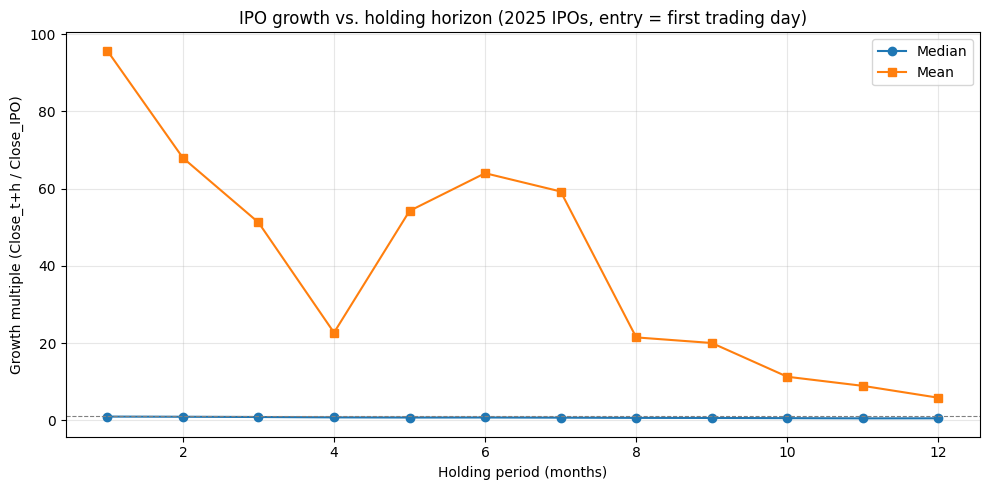

In [23]:
# ============================================================
# 8. Quick visual check (optional)
# ============================================================
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(trend['months'], trend['median'], marker='o', label='Median')
plt.plot(trend['months'], trend['mean'],   marker='s', label='Mean')
plt.axhline(1.0, color='grey', linestyle='--', linewidth=0.8)
plt.xlabel('Holding period (months)')
plt.ylabel('Growth multiple (Close_t+h / Close_IPO)')
plt.title('IPO growth vs. holding horizon (2025 IPOs, entry = first trading day)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Fourth Question

In [28]:
import gdown

# ============================================================
# 1. Download and load the parquet
# ============================================================
file_id = "1grCTCzMZKY5sJRtdbLVCXg8JXA8VPyg-"
gdown.download(f"https://drive.google.com/uc?id={file_id}", "data.parquet", quiet=False)

df = pd.read_parquet("data.parquet", engine="pyarrow")
print(f"Raw rows: {len(df):,}")

Downloading...
From (original): https://drive.google.com/uc?id=1grCTCzMZKY5sJRtdbLVCXg8JXA8VPyg-
From (redirected): https://drive.google.com/uc?id=1grCTCzMZKY5sJRtdbLVCXg8JXA8VPyg-&confirm=t&uuid=3c0c5ec7-9e4f-471b-bd7e-adc1445b7014
To: /content/data.parquet
100%|██████████| 130M/130M [00:01<00:00, 114MB/s]  


Raw rows: 229,932


In [29]:
# ============================================================
# 2. Confirm actual column names (case-sensitive!)
# ============================================================
# In this parquet the RSI column is lowercase 'rsi' and the date column is 'Date'
DATE_COL = "Date"
RSI_COL  = "rsi"
FWD_COL  = "growth_future_30d"

for c in (DATE_COL, RSI_COL, FWD_COL):
    assert c in df.columns, f"Missing column: {c}"

df[DATE_COL] = pd.to_datetime(df[DATE_COL])

In [30]:
# ============================================================
# 3. Strategy setup
# ============================================================
RSI_THRESHOLD = 30
INVESTMENT_PER_SIGNAL = 1_000

In [31]:
# ============================================================
# 4. Filter by date window + oversold signal + valid forward return
# ============================================================
mask = (
    (df[DATE_COL] >= pd.Timestamp("2000-01-01")) &
    (df[DATE_COL] <= pd.Timestamp("2025-06-01")) &
    (df[RSI_COL] < RSI_THRESHOLD) &
    (df[FWD_COL].notna())
)

selected_df = df.loc[mask].copy()
print(f"\nOversold signals (RSI < {RSI_THRESHOLD}) in window: {len(selected_df):,}")


Oversold signals (RSI < 30) in window: 5,206


In [32]:
# ============================================================
# 5. Profit calculation
# ============================================================
selected_df["net_income"] = INVESTMENT_PER_SIGNAL * (selected_df[FWD_COL] - 1)

total_profit = selected_df["net_income"].sum()
total_profit_thousands = total_profit / 1_000

print(f"\nTotal profit: ${total_profit:,.2f}  (${total_profit_thousands:,.2f} thousand)")
print(f"Average per trade: ${selected_df['net_income'].mean():,.2f}")


Total profit: $65,805.59  ($65.81 thousand)
Average per trade: $12.64


In [33]:
# ============================================================
# 6. Strategy summary
# ============================================================
n_trades       = len(selected_df)
avg_return     = selected_df[FWD_COL].mean() - 1
win_rate       = (selected_df[FWD_COL] > 1).mean()
total_invested = INVESTMENT_PER_SIGNAL * n_trades

print("\n=== Strategy summary ===")
print(f"Number of trades      : {n_trades:,}")
print(f"Total capital deployed: ${total_invested:,.0f}")
print(f"Average 30-day return : {avg_return:.4%}")
print(f"Win rate              : {win_rate:.2%}")
print(f"Total profit          : ${total_profit:,.2f}")
print(f"Return on capital     : {total_profit / total_invested:.2%}")


=== Strategy summary ===
Number of trades      : 5,206
Total capital deployed: $5,206,000
Average 30-day return : 1.2640%
Win rate              : 55.13%
Total profit          : $65,805.59
Return on capital     : 1.26%


In [34]:
# ============================================================
# 7. Yearly breakdown
# ============================================================
yearly = (
    selected_df
    .assign(year=selected_df[DATE_COL].dt.year)
    .groupby("year")
    .agg(
        trades=("net_income", "size"),
        total_pnl=("net_income", "sum"),
        avg_return=(FWD_COL, lambda s: s.mean() - 1),
        win_rate=(FWD_COL, lambda s: (s > 1).mean()),
    )
)
print("\n=== Yearly breakdown ===")
print(yearly.round(4).to_string())


=== Yearly breakdown ===
      trades   total_pnl  avg_return  win_rate
year                                          
2000     213   3060.4622      0.0144    0.5117
2001     300    201.7201      0.0007    0.5067
2002     304   6244.8060      0.0205    0.5658
2003     263   2315.5587      0.0088    0.1673
2004     305  11492.7627      0.0377    0.3705
2005     136   1626.0211      0.0120    0.6838
2006     148   3979.4028      0.0269    0.6622
2007     111    639.2045      0.0058    0.4955
2008     453   5488.8113      0.0121    0.5475
2009      78   2417.1953      0.0310    0.6667
2010     127   1853.8599      0.0146    0.6772
2011     242   4055.5959      0.0168    0.6281
2012     158   1616.9893      0.0102    0.5506
2013     164   2105.1929      0.0128    0.6159
2014     158   2029.5520      0.0128    0.6582
2015     144   3487.8922      0.0242    0.7222
2016     235   1496.0807      0.0064    0.5660
2017      55   1300.1411      0.0236    0.6364
2018     238   4720.8532      0.01

In [35]:
# ============================================================
# 8. Threshold sensitivity
# ============================================================
rows = []
for thr in [20, 25, 30, 35, 40]:
    sub = df[
        (df[DATE_COL] >= pd.Timestamp("2000-01-01")) &
        (df[DATE_COL] <= pd.Timestamp("2025-06-01")) &
        (df[RSI_COL] < thr) &
        (df[FWD_COL].notna())
    ]
    pnl = INVESTMENT_PER_SIGNAL * (sub[FWD_COL] - 1).sum()
    rows.append({
        "RSI_threshold": thr,
        "n_trades": len(sub),
        "avg_return": sub[FWD_COL].mean() - 1,
        "win_rate": (sub[FWD_COL] > 1).mean(),
        "total_profit_$k": pnl / 1_000,
    })

print("\n=== Threshold sensitivity ===")
print(pd.DataFrame(rows).round(4).to_string(index=False))


=== Threshold sensitivity ===
 RSI_threshold  n_trades  avg_return  win_rate  total_profit_$k
            20       455      0.0307    0.4659          13.9738
            25      1568      0.0155    0.5561          24.2955
            30      5206      0.0126    0.5513          65.8056
            35     13216      0.0099    0.5673         130.7143
            40     27926      0.0076    0.5599         213.1294
